In [61]:
import pickle
import pandas
import matplotlib.pyplot as plt
import pandas as pd

In [62]:
with open("../tracker_stubs/ball_detections.pkl", "rb") as f:
    ball_positions = pickle.load(f)
with open("../tracker_stubs/player_detections.pkl", "rb") as f:
    players_positions = pickle.load(f)


In [63]:
players_positions

{0: ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'player'}
 obb: None
 orig_img: array([[[ 48,  45,  46],
         [ 48,  45,  46],
         [ 47,  44,  45],
         ...,
         [ 36,  39,  37],
         [ 36,  39,  37],
         [ 36,  39,  37]],
 
        [[ 54,  51,  52],
         [ 54,  51,  52],
         [ 52,  49,  50],
         ...,
         [ 36,  39,  37],
         [ 36,  39,  37],
         [ 36,  39,  37]],
 
        [[ 59,  62,  62],
         [ 59,  62,  62],
         [ 59,  62,  62],
         ...,
         [ 37,  40,  38],
         [ 37,  40,  38],
         [ 37,  40,  38]],
 
        ...,
 
        [[112, 125,  78],
         [112, 125,  78],
         [111, 124,  77],
         ...,
         [146, 157,  96],
         [146, 157,  96],
         [146, 157,  96]],
 
        [[112, 125,  78],
         [112, 125,  78],
         [111, 124,  77],
         ...,
         [146, 

In [64]:
rows = []
for frame_idx, res in ball_positions.items():
    # res — это ultralytics.engine.results.Results
    boxes = res.boxes  # Boxes object
    
    if boxes is not None and len(boxes.xyxy) > 0:
        # Получаем первый бокс: tensor([x1, y1, x2, y2])
        # Конвертируем в Python list
        coords = boxes.xyxy[0].cpu().numpy().tolist()
        x1, y1, x2, y2 = coords
    else:
        # Если мяч не найден
        x1 = y1 = x2 = y2 = None

    rows.append({
        'frame_idx': frame_idx,
        'x1': x1,
        'y1': y1,
        'x2': x2,
        'y2': y2
    })

In [65]:
df_ball_positions = (
    pd.DataFrame(rows)
      .sort_values('frame_idx')
      .reset_index(drop=True)
)

print(df_ball_positions)

     frame_idx          x1          y1          x2          y2
0            0  433.389038  240.431580  451.032104  265.842590
1            1  433.286499  240.361206  450.670166  265.881958
2            2  432.817993  247.454224  449.979858  271.638062
3            3         NaN         NaN         NaN         NaN
4            4  426.423584  243.373962  444.859314  264.418030
..         ...         ...         ...         ...         ...
253        253         NaN         NaN         NaN         NaN
254        254         NaN         NaN         NaN         NaN
255        255  665.992798  308.395874  683.795776  332.901001
256        256  626.036743  253.260773  647.833862  276.587738
257        257  631.900391  253.077393  654.032715  281.102295

[258 rows x 5 columns]


In [66]:
df_ball_positions = pd.DataFrame(rows).sort_values('frame_idx').reset_index(drop=True)

In [67]:
df_ball_positions

,frame_idx,x1,y1,x2,y2
0,0,433.389038,240.431580,451.032104,265.842590
1,1,433.286499,240.361206,450.670166,265.881958
2,2,432.817993,247.454224,449.979858,271.638062
3,3,NaN,NaN,NaN,NaN
4,4,426.423584,243.373962,444.859314,264.418030
...,...,...,...,...,...
253,253,NaN,NaN,NaN,NaN
254,254,NaN,NaN,NaN,NaN
255,255,665.992798,308.395874,683.795776,332.901001
256,256,626.036743,253.260773,647.833862,276.587738


In [68]:
df_ball_positions = df_ball_positions.interpolate().bfill()

In [70]:
df_ball_positions['mid_y'] = (df_ball_positions['y1'] + df_ball_positions['y2']) / 2
df_ball_positions['mid_y_rolling_mean'] = df_ball_positions['mid_y'].rolling(window=5, min_periods=1, center=False).mean()

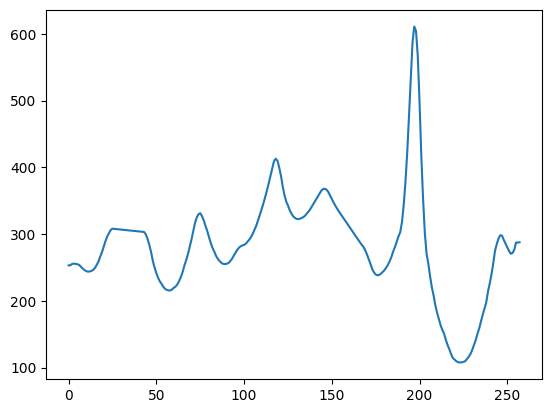

In [71]:
plt.plot(df_ball_positions["mid_y_rolling_mean"])

In [72]:
df_ball_positions["delta_y"] = df_ball_positions["mid_y_rolling_mean"].diff()

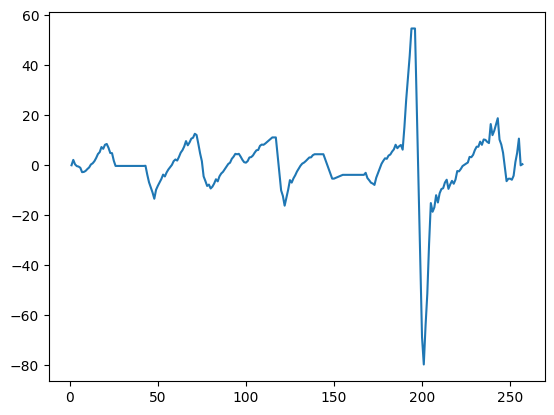

In [73]:
plt.plot(df_ball_positions["delta_y"])

In [74]:
df_ball_positions['ball_hit']=0


In [ ]:

minimum_change_frames_for_hit = 10
for i in range(1,len(df_ball_positions)- int(minimum_change_frames_for_hit*1.2) ):
    negative_position_change = df_ball_positions['delta_y'].iloc[i] >0 and df_ball_positions['delta_y'].iloc[i+1] <0
    positive_position_change = df_ball_positions['delta_y'].iloc[i] <0 and df_ball_positions['delta_y'].iloc[i+1] >0

    if negative_position_change or positive_position_change:
        change_count = 0 
        for change_frame in range(i+1, i+int(minimum_change_frames_for_hit*1.2)+1):
            negative_position_change_following_frame = df_ball_positions['delta_y'].iloc[i] >0 and df_ball_positions['delta_y'].iloc[change_frame] <0
            positive_position_change_following_frame = df_ball_positions['delta_y'].iloc[i] <0 and df_ball_positions['delta_y'].iloc[change_frame] >0

            if negative_position_change and negative_position_change_following_frame:
                change_count+=1
            elif positive_position_change and positive_position_change_following_frame:
                change_count+=1
    
        if change_count>minimum_change_frames_for_hit-1:
            df_ball_positions['ball_hit'].iloc[i] = 1

frame_nums_with_ball_hits = df_ball_positions[df_ball_positions['ball_hit']==1].index.tolist()
# for frame_num in frame_nums_with_ball_hits:
#     # Вычисляем центр мяча на основе现有 столбцов
#     ball_x = (df_ball_positions.at[frame_num, 'x1'] + df_ball_positions.at[frame_num, 'x2']) / 2
#     ball_y = (df_ball_positions.at[frame_num, 'y1'] + df_ball_positions.at[frame_num, 'y2']) / 2
    
#     # Проверяем наличие данных по игрокам для текущего кадра
#     if frame_num >= len(players_positions):
#         df_ball_positions.at[frame_num, 'ball_hit'] = 0
#         continue
    
#     results = players_positions[frame_num]
#     if not hasattr(results, 'boxes') or results.boxes is None:
#         df_ball_positions.at[frame_num, 'ball_hit'] = 0
#         continue
    
#     # Извлекаем bbox игроков (преобразуем в numpy array)
#     try:
#         boxes = results.boxes.xyxy.cpu().numpy()  # Для YOLOv8
#     except AttributeError:
#         boxes = results.boxes.data.numpy()       # Для старых версий
        
#     hit_found = False
    
#     for box in boxes:
#         x_min, y_min, x_max, y_max = map(float, box[:4])  # Берем только координаты bbox
#         center_player_x = (x_min + x_max) / 2
#         center_player_y = (y_min + y_max) / 2
        
#         # Проверка 1: Мяч внутри bbox игрока
#         if x_min <= ball_x <= x_max and y_min <= ball_y <= y_max:
#             hit_found = True
#             break
        
#         # Проверка 2: Расстояние до центра игрока < порога (30 пикселей)
#         distance = ((ball_x - center_player_x)**2 + (ball_y - center_player_y)**2)**0.5
#         if distance < 150:
#             hit_found = True
#             break
    
#     if not hit_found:
#         df_ball_positions.at[frame_num, 'ball_hit'] = 0

C:\Users\user\AppData\Local\Temp\ipykernel_8724\2335204712.py:18: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_ball_positions['ball_hit'].iloc[i] = 1
C:\Users\user\AppData\Local\Temp\ipykernel_8724\2335204712.py:18: SettingWithCopyWarnin

In [76]:
frame_nums_with_ball_hits

[11, 25, 57, 75, 89, 118, 131, 146, 176, 197, 223]

In [35]:
frame_nums_with_ball_hits_ = df_ball_positions[df_ball_positions['ball_hit'] == 1].index.tolist()

In [36]:
ball_positions

{0: ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'ball'}
 obb: None
 orig_img: array([[[ 83,  95, 105],
         [ 83,  95, 105],
         [ 83,  95, 105],
         ...,
         [ 66,  83,  92],
         [ 66,  83,  92],
         [ 66,  83,  92]],
 
        [[ 83,  95, 105],
         [ 83,  95, 105],
         [ 83,  95, 105],
         ...,
         [ 66,  83,  92],
         [ 66,  83,  92],
         [ 66,  83,  92]],
 
        [[ 85,  97, 107],
         [ 85,  97, 107],
         [ 85,  97, 107],
         ...,
         [ 67,  84,  93],
         [ 67,  84,  93],
         [ 67,  84,  93]],
 
        ...,
 
        [[128, 121,  74],
         [128, 121,  74],
         [128, 123,  69],
         ...,
         [146, 145,  91],
         [146, 145,  91],
         [146, 145,  91]],
 
        [[128, 121,  74],
         [128, 121,  74],
         [128, 123,  69],
         ...,
         [146, 14

In [80]:
def get_ball_shot_frames(ball_positions):
        rows = []
        
        for frame_idx, res in ball_positions.items():
    # res — это ultralytics.engine.results.Results
            boxes = res.boxes  # Boxes object
            
            if boxes is not None and len(boxes.xyxy) > 0:
                # Получаем первый бокс: tensor([x1, y1, x2, y2])
                # Конвертируем в Python list
                coords = boxes.xyxy[0].cpu().numpy().tolist()
                x1, y1, x2, y2 = coords
            else:
                # Если мяч не найден
                x1 = y1 = x2 = y2 = None

            rows.append({
                'frame_idx': frame_idx,
                'x1': x1,
                'y1': y1,
                'x2': x2,
                'y2': y2
            })

        df_ball_positions = (
                pd.DataFrame(rows)
                .sort_values('frame_idx')
                .reset_index(drop=True)
                )
        df_ball_positions = df_ball_positions.interpolate().bfill()
        df_ball_positions['mid_y'] = (df_ball_positions['y1'] + df_ball_positions['y2']) / 2
        df_ball_positions['mid_y_rolling_mean'] = df_ball_positions['mid_y'].rolling(window=5, min_periods=1, center=False).mean()
        df_ball_positions["delta_y"] = df_ball_positions["mid_y_rolling_mean"].diff()
        df_ball_positions['ball_hit'] = 0

        minimum_change_frames_for_hit = 5
        for i in range(1,len(df_ball_positions)- int(minimum_change_frames_for_hit*1.2) ):
            negative_position_change = df_ball_positions['delta_y'].iloc[i] >0 and df_ball_positions['delta_y'].iloc[i+1] <0
            positive_position_change = df_ball_positions['delta_y'].iloc[i] <0 and df_ball_positions['delta_y'].iloc[i+1] >0

            if negative_position_change or positive_position_change:
                change_count = 0 
                for change_frame in range(i+1, i+int(minimum_change_frames_for_hit*1.2)+1):
                    negative_position_change_following_frame = df_ball_positions['delta_y'].iloc[i] >0 and df_ball_positions['delta_y'].iloc[change_frame] <0
                    positive_position_change_following_frame = df_ball_positions['delta_y'].iloc[i] <0 and df_ball_positions['delta_y'].iloc[change_frame] >0

                    if negative_position_change and negative_position_change_following_frame:
                        change_count+=1
                    elif positive_position_change and positive_position_change_following_frame:
                        change_count+=1
            
                if change_count>minimum_change_frames_for_hit-1:
                    df_ball_positions['ball_hit'].iloc[i] = 1

        frame_nums_with_ball_hits = df_ball_positions[df_ball_positions['ball_hit']==1].index.tolist()
        return frame_nums_with_ball_hits

In [81]:
print(get_ball_shot_frames(ball_positions))

[3, 11, 25, 57, 75, 89, 118, 131, 146, 176, 197, 223, 246]


C:\Users\user\AppData\Local\Temp\ipykernel_8724\3832132068.py:53: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_ball_positions['ball_hit'].iloc[i] = 1
C:\Users\user\AppData\Local\Temp\ipykernel_8724\3832132068.py:53: SettingWithCopyWarnin

In [83]:
import numpy as np
import pandas as pd

rows = []
# 1) Собираем сырые координаты мяча в DataFrame
for frame_idx, res in ball_positions.items():
    # res — это ultralytics.engine.results.Results с найденными боксами мяча
    boxes = res.boxes
    if boxes is not None and len(boxes.xyxy) > 0:
        coords = boxes.xyxy[0].cpu().numpy().tolist()
        x1, y1, x2, y2 = coords
    else:
        x1 = y1 = x2 = y2 = None

    rows.append({
        'frame_idx': frame_idx,
        'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2
    })

df = pd.DataFrame(rows).sort_values('frame_idx').reset_index(drop=True)
# Интерполируем пропуски (если при детекции мяча ничего не нашли)
df = df.interpolate().bfill()


df['mid_x'] = (df['x1'] + df['x2']) / 2
df['mid_y'] = (df['y1'] + df['y2']) / 2
df['mid_y_rolling_mean'] = df['mid_y'].rolling(window=5, min_periods=1).mean()
df['delta_y'] = df['mid_y_rolling_mean'].diff()
df['ball_hit'] = 0  # метка “потенциальный удар”


minimum_change_frames_for_hit = 5
length = len(df)
for i in range(1, length - int(minimum_change_frames_for_hit * 1.2)):
    # проверяем, в i-ом кадре траектория меняет знак на следующем
    negative_position_change = (df['delta_y'].iloc[i] > 0 and df['delta_y'].iloc[i + 1] < 0)
    positive_position_change = (df['delta_y'].iloc[i] < 0 and df['delta_y'].iloc[i + 1] > 0)

    if negative_position_change or positive_position_change:
        change_count = 0
        
        for change_frame in range(i + 1, i + int(minimum_change_frames_for_hit * 1.2) + 1):
            neg_follow = (df['delta_y'].iloc[i] > 0 and df['delta_y'].iloc[change_frame] < 0)
            pos_follow = (df['delta_y'].iloc[i] < 0 and df['delta_y'].iloc[change_frame] > 0)
            if negative_position_change and neg_follow:
                change_count += 1
            elif positive_position_change and pos_follow:
                change_count += 1

        if change_count > minimum_change_frames_for_hit - 1:
            df.at[i, 'ball_hit'] = 1


candidate_hit_indices = df[df['ball_hit'] == 1].index.tolist()

# Фильтруем эти индексы по “наличию игрока рядом”
true_hit_indices = []
for idx in candidate_hit_indices:
    ball_x = df.at[idx, 'mid_x']
    ball_y = df.at[idx, 'mid_y']

    # Получаем результат детекции игроков в этом кадре:
    player_res = players_positions[idx]
    player_boxes = player_res.boxes  # объекты ultralytics.engine.results.Boxes, с .xyxy

    # Если боксов нет — значит игроков не засекли, пропускаем
    if player_boxes is None or len(player_boxes.xyxy) == 0:
        continue

    
    someone_near = False
    for box_tensor in player_boxes.xyxy:
        coords = box_tensor.cpu().numpy().tolist()
        px1, py1, px2, py2 = coords
        player_cx = (px1 + px2) / 2
        player_cy = (py1 + py2) / 2

        # Евклидово расстояние в пикселях:
        dist_pixels = float(np.sqrt((ball_x - player_cx) ** 2 + (ball_y - player_cy) ** 2))

        # Считаем, что игрок “рядом”, если dist_pixels < proximity_threshold_pixels
        if dist_pixels < 140:
            someone_near = True
            break

    if someone_near:
        true_hit_indices.append(idx)
    

print(true_hit_indices)

[25, 75, 118, 131, 197, 246]
